In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dane do Zadania 1: Sparklines (3 produkty przez 12 miesięcy)
months = np.arange(1, 13)
spark_data = {
    'Zysk Alpha': np.cumsum(np.random.normal(1, 2, 12)) + 20,
    'Zysk Beta': np.cumsum(np.random.normal(-0.5, 1.5, 12)) + 15,
    'Zysk Gamma': np.cumsum(np.random.normal(2, 3, 12)) + 10
}

# Dane do Zadania 2: Annotated Time Series
years = np.arange(2000, 2025)
stock_price = 100 + np.cumsum(np.random.normal(0, 8, len(years)))

# Dane do Zadania dodatkowego A
categories_dp =['Wydział IT', 'Wydział HR', 'Wydział Sprzedaży', 'Wydział Marketingu', 'Zarząd']
values_dp = [85, 70, 60, 40, 20]

## 1. Make-over: Sparklines (Iskierki)
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 171)*

Tufte ukuł termin **Sparklines** (Iskierki), określając je mianem "intensywnych informacyjnie, małych grafik wielkości słowa". Ich celem jest pokazanie trendu i zmienności danych w sposób tak skondensowany, że można je wpleść bezpośrednio w tekst lub tabele. Zgodnie z filozofią maksymalizacji *Data-Ink Ratio*, iskierki są całkowicie pozbawione osi, ramek, siatek czy zbędnych liczb.

W tym zadaniu zbudujemy siatkę 3 małych wykresów pokazujących trendy dla 3 różnych produktów, stosując zasady minimalizmu.

**Instrukcja krok po kroku:**
1. Stwórz układ składający się z 3 wierszy i 1 kolumny używając funkcji `fig, axes = plt.subplots(3, 1, figsize=(6, 3))`. Aby wykresy nie nachodziły na siebie, ustaw odstępy między wierszami za pomocą `plt.subplots_adjust(hspace=0.8)`.
2. Wykorzystaj pętlę `for ax, (name, values) in zip(axes, spark_data.items()):`, aby przeiterować przez przygotowane osie oraz dane produktów.
3. Wewnątrz pętli: narysuj linię trendu na bieżącej osi (`ax`) za pomocą funkcji `plot()`. Użyj koloru czarnego i grubości linii `linewidth=1`.
4. Usuń całkowicie układ współrzędnych (linie osi, liczby, ramki) z każdego małego wykresu poleceniem `ax.axis('off')`.
5. Dodaj na początku każdej linii nazwę produktu: użyj funkcji `ax.text()` ze współrzędnymi X wyznaczonymi przez pierwszy miesiąc (`months[0]`) oraz Y przez pierwszą wartość (`values[0]`). Ustaw parametr `ha='right'` (wyrównanie do prawej), aby tekst znalazł się przed linią, oraz `va='center'`.
6. Na końcu każdej linii dodaj małą czarną kropkę oznaczającą ostatnią zanotowaną wartość. Użyj funkcji `ax.scatter()` dla ostatniego elementu list `months` i `values`. Ustaw kolor na `'black'`, rozmiar `s=15` oraz `zorder=3`.
7. Na prawo od czerwonej kropki dopisz dokładną wartość liczbową: ponownie użyj funkcji `ax.text()`, ustawiając kolor na czerwony i formatując liczbę do jednego miejsca po przecinku (np. `f' {values[-1]:.1f}'`).

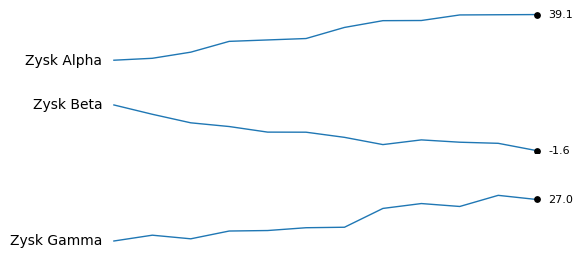

In [3]:
#@title Miejsce na Twój kod
fig, axes = plt.subplots(3, 1, figsize=(6, 3))
plt.subplots_adjust(hspace=0.8)
for ax, (name, values) in zip(axes, spark_data.items()):
    ax.plot(months, values, linewidth=1)
    ax.axis('off')
    ax.text(months[0] - 0.3, values[0], name, ha='right', va='center')
    ax.scatter(months[-1], values[-1], color='black', s=15, zorder=3)
    ax.text(months[-1] + 0.3, values[-1], f'{values[-1]:.1f}', ha='left', va='center', fontsize=8, color='black')

## 2. Make-over: Data-ink we wskaźnikach i adnotacjach
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 177–180)*

Edward Tufte promuje zasadę integrowania tekstu, liczb i obrazu (tzw. *Direct Annotation*). Według niego, zamiast zmuszać czytelnika do szukania wartości na bocznej osi, lepiej opisać kluczowe punkty danych bezpośrednio na wykresie.

W tym przykładzie usuniemy całą oś Y. Jej rolę przejmą dwie adnotacje: dla **maksimum** i **minimum** historycznego. Dzięki temu "atrament" zużyty na ramki i siatkę siatkę osi Y zostaje zastąpiony czystą informacją.

**Instrukcja krok po kroku:**
1. Na `ax1` narysuj standardową linię: `ax1.plot(years, stock_price)`. Zostaw domyślne ramki i osie.
2. Na `ax2` narysuj tę samą linię, ustaw kolor `'dimgray'`, grubość `linewidth=2` i wyłącz znaczniki danych.
3. Znajdź wartości skrajne:
   - Maksimum: `max_idx = np.argmax(stock_price)`, wyciągnij `max_val` oraz `max_year = years[max_idx]`.
   - Minimum: `min_idx = np.argmin(stock_price)`, wyciągnij `min_val` oraz `min_year = years[min_idx]`.
4. Usuń górną, prawą i lewą ramkę osi na `ax2` (`spines['...'].set_visible(False)`). Wyłączamy lewą oś, bo konkretne liczby podamy w adnotacjach.
5. Ukryj wszystkie znaczniki i liczby na osi Y: `ax2.tick_params(left=False, labelleft=False)`.
6. Dodaj adnotację dla **maksimum**: użyj `ax2.annotate()`. Punktem docelowym (`xy`) jest najwyższy punkt, a tekst (`xytext`) umieść nieco obok. Dodaj strzałkę `arrowprops`.
7. Dodaj adnotację dla **minimum**: analogicznie użyj `ax2.annotate()`. Dobierz `xytext` tak, aby napis nie nachodził na linię wykresu (np. przesuń go w dół).
8. Zastosuj zasadę *Range-frame* dla osi X: przytnij dolną ramkę dokładnie do zakresu lat (`set_bounds`).

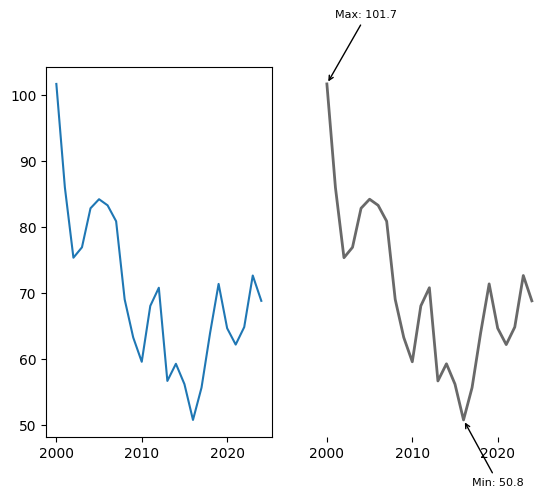

In [4]:
#@title Miejsce na Twój kod
ax1 = plt.subplot(1, 2, 1)
ax1.plot(years, stock_price)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(years, stock_price, color='dimgray', linewidth=2)
max_idx = np.argmax(stock_price)
max_val, max_year = stock_price[max_idx], years[max_idx]
min_idx = np.argmin(stock_price)
min_val, min_year = stock_price[min_idx], years[min_idx]
for spine in ['bottom', 'left', 'right', 'top']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax2.annotate(f'Max: {max_val:.1f}', xy=(max_year, max_val), xytext=(max_year + 1, max_val + 10), arrowprops=dict(arrowstyle='->', color='black'), fontsize=8, color='black')
ax2.annotate(f'Min: {min_val:.1f}', xy=(min_year, min_val), xytext=(min_year + 1, min_val - 10), arrowprops=dict(arrowstyle='->', color='black'), fontsize=8, color='black')
ax2.spines['bottom'].set_bounds(years.min(), years.max())


## Zadania dodatkowe dla chętnych

### A. Cleveland Dot Plot zamiast wykresu słupkowego
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 126–128)*

Tufte często sugeruje zastąpienie ciężkiego, horyzontalnego wykresu słupkowego za pomocą tzw. **Cleveland Dot Plot**. Zamiast grubych bloków koloru, które zajmują dużo miejsca, a nie niosą dodatkowej informacji, używamy cienkich linii pomocniczych i kropek. Taki zabieg drastycznie zwiększa wskaźnik *Data-Ink Ratio*.

**Instrukcja krok po kroku:**
1. Stwórz układ dwóch subplotów obok siebie używając `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`.
2. Na lewym subplocie (`ax1`) narysuj standardowy wykres słupkowy poziomy za pomocą funkcji `barh()`, wykorzystując zmienne `categories_dp` oraz `values_dp`. Ustaw kolor słupków na `'steelblue'`.
3. Na prawym subplocie (`ax2`) zamiast słupków narysuj poziome linie pomocnicze (prowadnice) funkcją `ax2.hlines()`. Jako parametry podaj: `y=categories_dp`, `xmin=0` oraz `xmax=values_dp`. Ustaw kolor na `'gray'`, szerokość linii `linewidth=1` oraz styl linii `linestyle='--'`.
4. Dodaj kropki na końcach linii pomocniczych za pomocą funkcji `ax2.plot()`. Użyj danych `(values_dp, categories_dp)`, ustaw symbol kropki `'o'`, kolor czarny, wielkość znacznika `markersize=8` oraz `zorder=3` (aby kropki były widoczne nad liniami).
5. Oczyść `ax2` ze zbędnego atramentu: usuń wszystkie cztery ramki (`top`, `right`, `left`, `bottom`) używając pętli po `ax2.spines`.
6. Usuń wszystkie znaczniki osi (ticks) na `ax2` poleceniem `ax2.tick_params(axis='both', which='both', length=0)`, pozostawiając jedynie podpisy kategorii.
7. Dodaj odpowiednie tytuły do obu wykresów i wyświetl całość.

### B. Proporcje wykresu (Aspect Ratio) i "Złoty podział"
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 186–190)*

Tufte opisuje zasadę "banking to 45 degrees" – twierdzi, że proporcje wykresu mają kluczowe znaczenie dla interpretacji trendów. Jeśli wykres szeregu czasowego jest zbyt wysoki (kwadratowy), zmiany wydają się gwałtowne i chaotyczne. Jeśli jest odpowiednio szeroki i niski, oko łatwiej wyłapuje długofalowy trend, ignorując drobny szum.

**Instrukcja krok po kroku:**
1. Wygeneruj pierwszy wykres, wymuszając proporcje kwadratowe za pomocą `plt.figure(figsize=(5, 5))`. Narysuj na nim dane giełdowe `stock_price` względem lat. Nadaj mu tytuł "Wersja kwadratowa". Zauważ, jak poszarpana wydaje się linia.
2. Wygeneruj drugi wykres w nowej komórce (lub pod spodem), wymuszając proporcje horyzontalne za pomocą `plt.figure(figsize=(15, 3))`. Narysuj te same dane.
3. W wersji horyzontalnej zastosuj szlif Tufte'owski: usuń górną i prawą ramkę osi (`spines`).
4. Porównaj oba wykresy. Zwróć uwagę, jak zmiana samych proporcji okna (`figsize`) sprawia, że ten sam zestaw danych staje się optycznie "wygładzony", a prawdziwy, długoterminowy trend wzrostowy staje się bardziej oczywisty niż lokalne wahania.

Text(0.5, 1.0, 'Wykres słupkowy z linii')

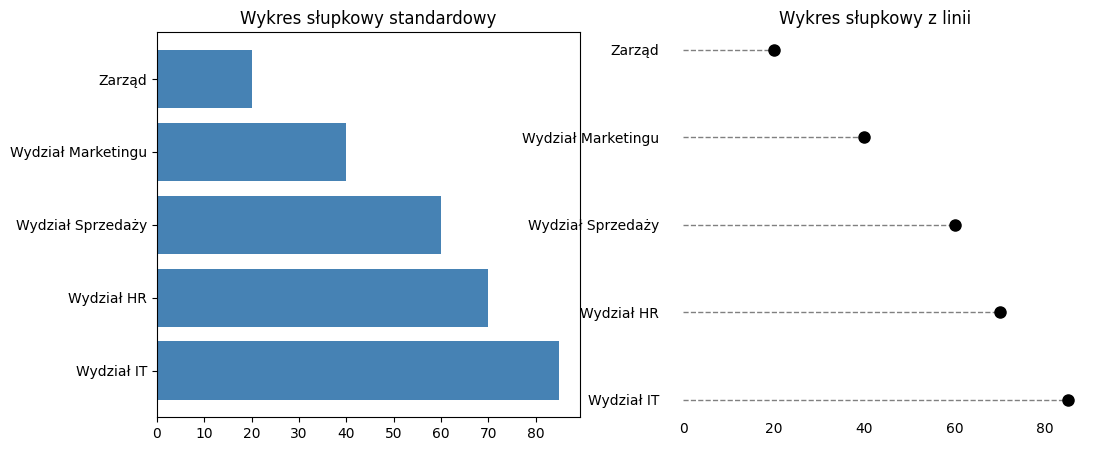

In [ ]:
#@title Miejsce na Twój kod
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.barh(categories_dp, values_dp, color='steelblue')
ax1.set_title('Wykres słupkowy standardowy')

ax2.hlines(y=categories_dp, xmin=0, xmax=values_dp, color='gray', linewidth=1, linestyle='--')
ax2.plot(values_dp, categories_dp, 'o', color='black', markersize=8, zorder=3)
for spine in ['bottom', 'left', 'right', 'top']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(axis='both', which='both', length=0)
ax2.set_title('Wykres słupkowy z linii')

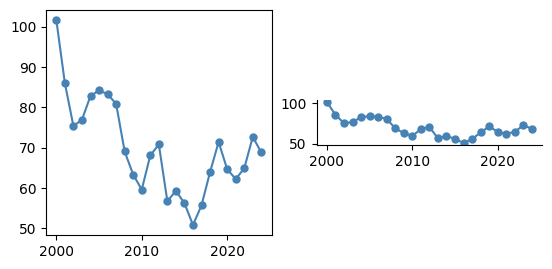

In [18]:
#@title Miejsce na Twój kod
ax1 = plt.subplot(1, 2, 1)
ax1.set_box_aspect(1)
ax1.plot(years, stock_price, 'o-', color='steelblue', markersize=5)

ax2 = plt.subplot(1, 2, 2)
ax2.set_box_aspect(1/5)
ax2.plot(years, stock_price, 'o-', color='steelblue', markersize=5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)